# Exploration des données — Telco Customer Churn

Analyse exploratoire (EDA) du dataset utilisé par le pipeline MLOps. Objectifs :

1. Comprendre la structure et la qualité des données brutes (types, valeurs manquantes, doublons)
2. Étudier la cible `Churn` et son déséquilibre
3. Identifier les variables les plus liées au churn (numériques et catégorielles)
4. En déduire les choix de preprocessing implémentés dans `src/data.py` et `src/pipeline.py`

> Les données brutes sont téléchargées par `make data` (`data/raw/telco_churn.csv`). Les figures sont sauvegardées dans `reports/figures/` pour le rapport.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.utils import PROJECT_ROOT, load_config, resolve

%matplotlib inline
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 110

cfg = load_config()
FIG_DIR = PROJECT_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

def save(name):
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{name}.png", bbox_inches="tight")
    plt.show()

raw_path = resolve(cfg["data"]["raw_path"])
if not raw_path.exists():
    from src.data import download
    download(cfg["data"]["url"], raw_path)
raw = pd.read_csv(raw_path)
print(f"Dataset brut : {raw.shape[0]} lignes x {raw.shape[1]} colonnes")

C:\Users\fatim\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset brut : 7043 lignes x 21 colonnes


## 1. Aperçu des données brutes

In [2]:
raw.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Observations :
- `customerID` est un identifiant unique → non prédictif, à supprimer.
- `TotalCharges` est typé **object** alors que c'est un montant : il contient des valeurs non numériques.
- `SeniorCitizen` est encodé en 0/1 (int) alors que c'est sémantiquement une catégorie.

## 2. Qualité des données

In [4]:
quality = pd.DataFrame({
    "dtype": raw.dtypes,
    "n_unique": raw.nunique(),
    "n_missing": raw.isna().sum(),
    "n_blank": raw.apply(lambda s: (s.astype(str).str.strip() == "").sum()),
})
quality

,dtype,n_unique,n_missing,n_blank
customerID,object,7043,0,0
gender,object,2,0,0
SeniorCitizen,int64,2,0,0
Partner,object,2,0,0
Dependents,object,2,0,0
tenure,int64,73,0,0
PhoneService,object,2,0,0
MultipleLines,object,3,0,0
InternetService,object,3,0,0
OnlineSecurity,object,3,0,0


In [5]:
tc_numeric = pd.to_numeric(raw["TotalCharges"], errors="coerce")
blank = raw[tc_numeric.isna()][["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]]
print(f"TotalCharges non numériques : {len(blank)} lignes")
print(f"Doublons exacts (hors customerID) : {raw.drop(columns='customerID').duplicated().sum()}")
blank

TotalCharges non numériques : 11 lignes
Doublons exacts (hors customerID) : 22


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


Les 11 `TotalCharges` vides correspondent tous à des clients avec `tenure = 0` (nouveaux clients, pas encore facturés).
Ce n'est donc pas une erreur de saisie mais une valeur **structurellement manquante** : on la convertit en `NaN` et on laisse le `SimpleImputer(median)` du pipeline la gérer plutôt que de supprimer ces lignes.

Les 22 doublons exacts (mêmes valeurs sur toutes les colonnes hors identifiant) sont supprimés par `src/data.py`.

## 3. Dataset nettoyé (sortie de `src/data.py`)

In [6]:
from src.data import clean
df = clean(raw, cfg)
NUM = cfg["features"]["numeric"]
CAT = cfg["features"]["categorical"]
TARGET = cfg["data"]["target"]
print(f"Après nettoyage : {df.shape[0]} lignes x {df.shape[1]} colonnes")
print(f"{len(NUM)} variables numériques : {NUM}")
print(f"{len(CAT)} variables catégorielles : {CAT}")
df.describe().T

Après nettoyage : 7021 lignes x 20 colonnes
3 variables numériques : ['tenure', 'MonthlyCharges', 'TotalCharges']
16 variables catégorielles : ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


,count,mean,std,min,25%,50%,75%,max
tenure,7021.0,32.469449,24.534965,0.00,9.0000,29.000,55.0000,72.00
MonthlyCharges,7021.0,64.851894,30.069001,18.25,35.7500,70.400,89.9000,118.75
TotalCharges,7010.0,2290.353388,2266.820832,18.80,408.3125,1403.875,3807.8375,8684.80


## 4. Variable cible : `Churn`

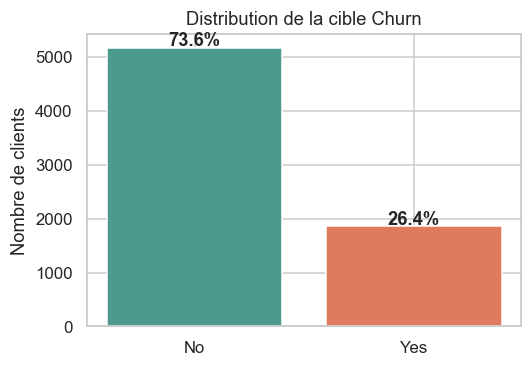

Churn
No     0.736
Yes    0.264
Name: proportion, dtype: float64


In [7]:
counts = df[TARGET].value_counts()
share = df[TARGET].value_counts(normalize=True)
fig, ax = plt.subplots(figsize=(5, 3.5))
bars = ax.bar(counts.index, counts.values, color=["#4C9A8E", "#E07A5F"])
for b, s in zip(bars, share.values):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 30, f"{s:.1%}", ha="center", fontweight="bold")
ax.set_title("Distribution de la cible Churn")
ax.set_ylabel("Nombre de clients")
save("target_distribution")
print(share.round(3))

La classe positive (`Yes`) représente **~26 %** des clients : déséquilibre modéré.
Conséquences pour le pipeline :
- split **stratifié** et `StratifiedKFold` en validation croisée ;
- métrique principale **ROC-AUC** (insensible au déséquilibre) plutôt que l'accuracy ;
- `class_weight="balanced"` inclus dans la grille d'hyperparamètres ;
- seuil de décision configurable (`evaluation.threshold`).

## 5. Variables numériques vs churn

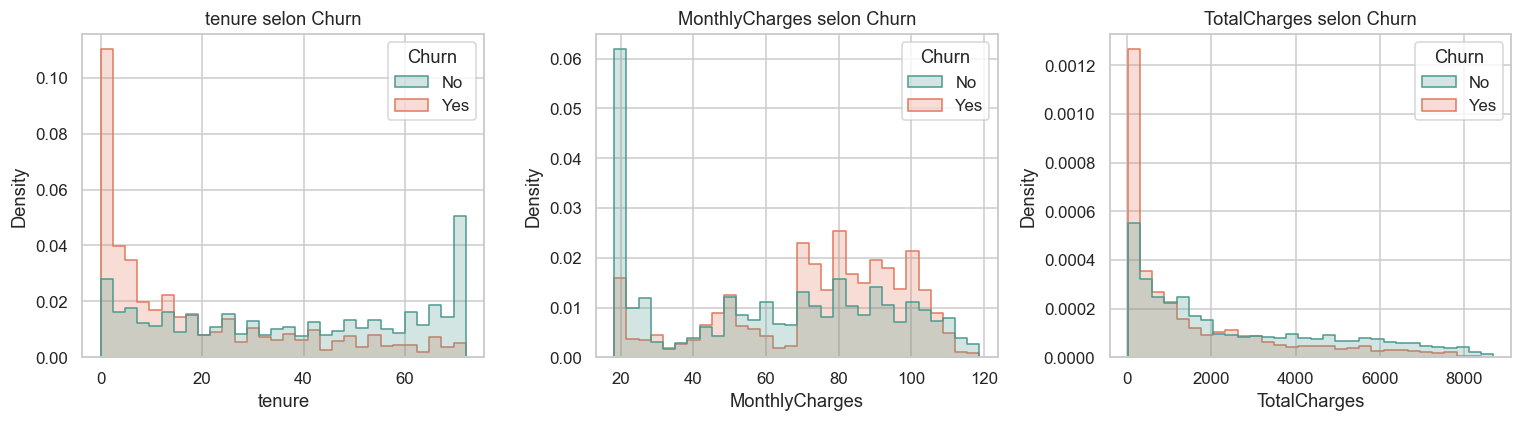

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, NUM):
    sns.histplot(data=df, x=col, hue=TARGET, bins=30, stat="density", common_norm=False,
                 element="step", ax=ax, palette={"No": "#4C9A8E", "Yes": "#E07A5F"})
    ax.set_title(f"{col} selon Churn")
save("numeric_distributions")

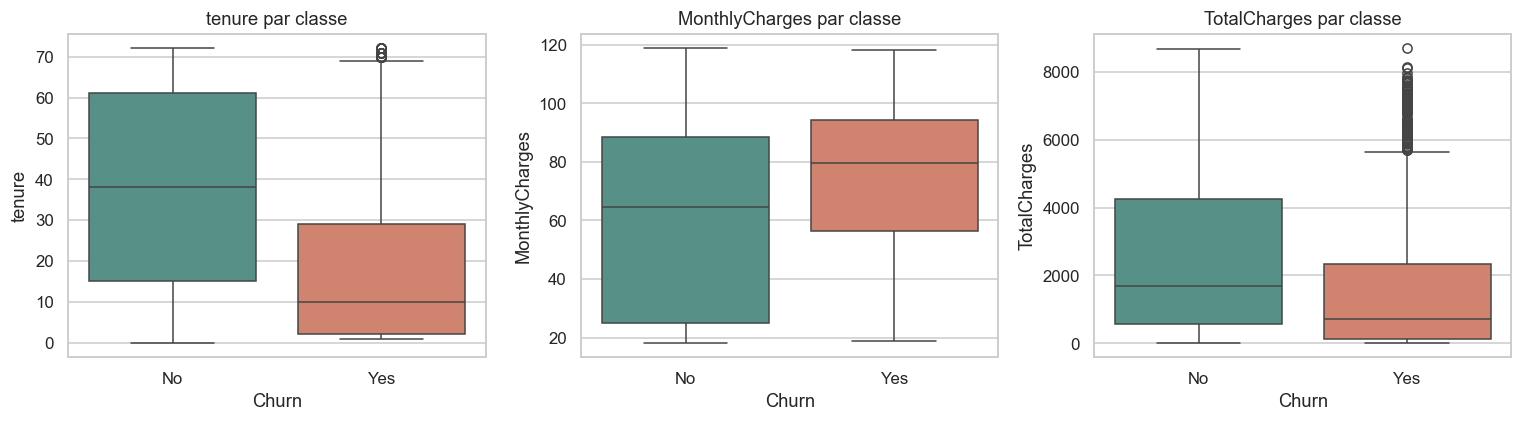

,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,38.0,64.5,1688.9
Yes,10.0,79.7,713.1


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, NUM):
    sns.boxplot(data=df, x=TARGET, y=col, ax=ax, palette={"No": "#4C9A8E", "Yes": "#E07A5F"})
    ax.set_title(f"{col} par classe")
save("numeric_boxplots")
df.groupby(TARGET)[NUM].median().round(2)

- **`tenure`** : les clients qui partent ont une ancienneté très faible (médiane ≈ 10 mois contre 38). C'est le prédicteur le plus fort.
- **`MonthlyCharges`** : le churn est associé à des factures mensuelles plus élevées (médiane ≈ 80 € contre 64 €).
- **`TotalCharges`** : essentiellement `tenure × MonthlyCharges`, donc fortement corrélé à `tenure` (voir §7).

Les échelles sont très différentes (0–72 mois vs 0–8 700 €) → `StandardScaler` dans le pipeline pour la régression logistique.

## 6. Variables catégorielles : taux de churn par modalité

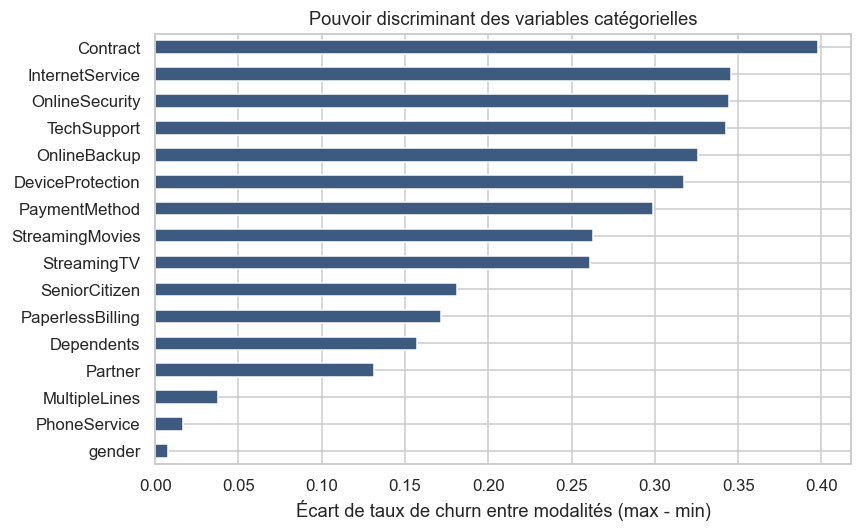

Contract            0.398
InternetService     0.346
OnlineSecurity      0.344
TechSupport         0.343
OnlineBackup        0.326
DeviceProtection    0.318
PaymentMethod       0.299
StreamingMovies     0.263
StreamingTV         0.261
SeniorCitizen       0.181
PaperlessBilling    0.171
Dependents          0.157
Partner             0.132
MultipleLines       0.038
PhoneService        0.017
gender              0.008
dtype: float64

In [10]:
churn_rates = {}
for col in CAT:
    r = df.groupby(col)[TARGET].apply(lambda s: (s == "Yes").mean()).sort_values(ascending=False)
    churn_rates[col] = r

# Écart max de taux de churn entre modalités = mesure simple du pouvoir discriminant
spread = pd.Series({c: r.max() - r.min() for c, r in churn_rates.items()}).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 5))
spread.plot.barh(ax=ax, color="#3D5A80")
ax.invert_yaxis()
ax.set_xlabel("Écart de taux de churn entre modalités (max - min)")
ax.set_title("Pouvoir discriminant des variables catégorielles")
save("categorical_spread")
spread.round(3)

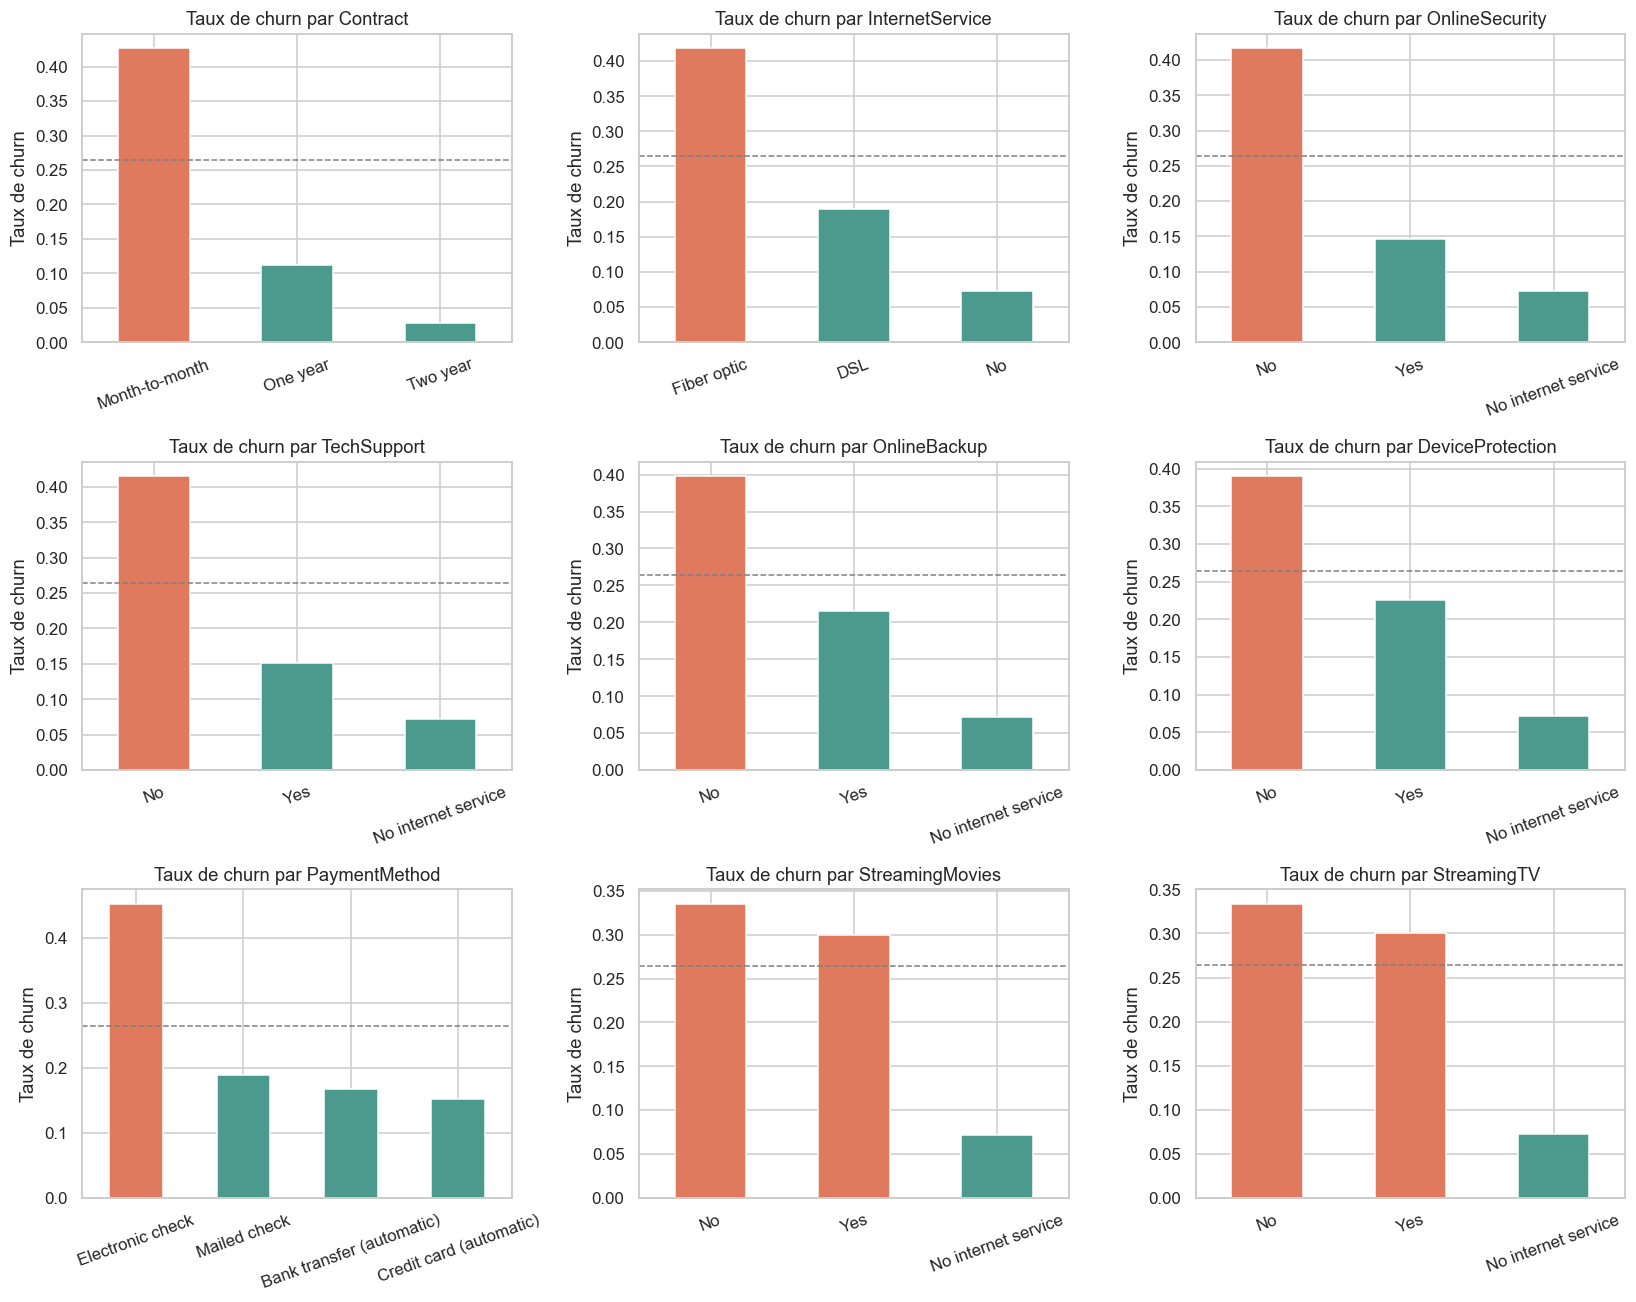

In [11]:
top = spread.index[:9]
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
base_rate = (df[TARGET] == "Yes").mean()
for ax, col in zip(axes.ravel(), top):
    r = churn_rates[col]
    r.plot.bar(ax=ax, color=["#E07A5F" if v > base_rate else "#4C9A8E" for v in r.values])
    ax.axhline(base_rate, ls="--", color="gray", lw=1)
    ax.set_title(f"Taux de churn par {col}")
    ax.set_ylabel("Taux de churn")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)
save("categorical_churn_rates")

Lecture (ligne pointillée = taux moyen 26 %) :
- **`Contract`** : 43 % de churn en *Month-to-month* contre 3 % en *Two year* — variable la plus discriminante.
- **`InternetService`** : la fibre optique churne à 42 % (prix élevé / concurrence), contre 7 % sans internet.
- **`OnlineSecurity` / `TechSupport`** : l'absence de ces services double le taux de churn.
- **`PaymentMethod`** : le chèque électronique (45 %) se démarque nettement des paiements automatiques (~16 %).
- `gender`, `PhoneService` : quasiment aucun effet — conservées mais peu utiles.

Toutes les modalités sont de faible cardinalité (2 à 4 valeurs) → `OneHotEncoder(handle_unknown="ignore")` est adapté et robuste à une modalité inconnue en production.

## 7. Corrélations

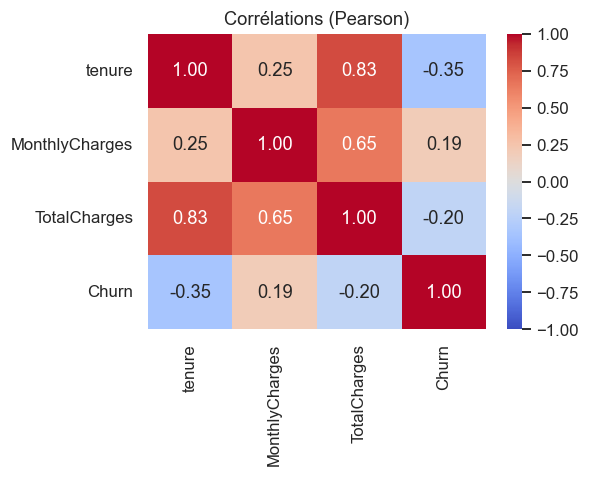

In [12]:
num_df = df[NUM].copy()
num_df["Churn"] = (df[TARGET] == "Yes").astype(int)
corr = num_df.corr()
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title("Corrélations (Pearson)")
save("correlation_heatmap")

`TotalCharges` est corrélé à 0.83 avec `tenure` (redondance attendue). Elle est conservée car les modèles utilisés (régression logistique régularisée, forêt aléatoire) tolèrent bien la colinéarité, et elle apporte une information sur le montant cumulé. `tenure` est la variable numérique la plus (négativement) liée au churn.

## 8. Interaction ancienneté × type de contrat

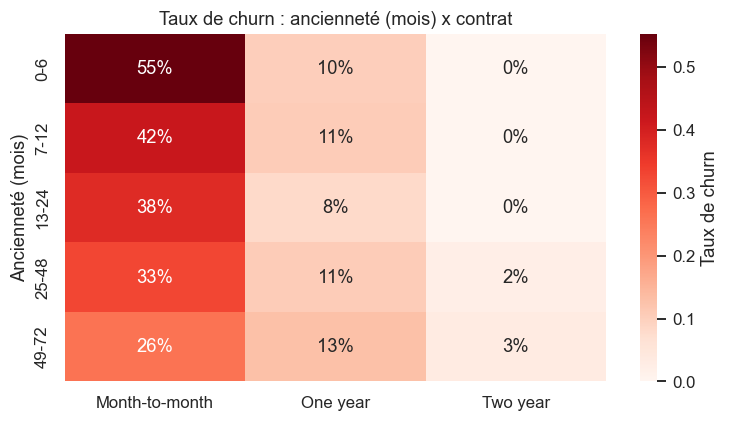

In [13]:
df["tenure_bin"] = pd.cut(df["tenure"], bins=[-1, 6, 12, 24, 48, 72], labels=["0-6", "7-12", "13-24", "25-48", "49-72"])
pivot = df.pivot_table(index="tenure_bin", columns="Contract", values=TARGET, aggfunc=lambda s: (s == "Yes").mean(), observed=True)
fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(pivot, annot=True, fmt=".0%", cmap="Reds", ax=ax, cbar_kws={"label": "Taux de churn"})
ax.set_title("Taux de churn : ancienneté (mois) x contrat")
ax.set_xlabel("")
ax.set_ylabel("Ancienneté (mois)")
save("tenure_contract_heatmap")
df.drop(columns="tenure_bin", inplace=True)

Le risque est concentré chez les **clients récents en contrat mensuel** (plus de 50 % de churn dans les 6 premiers mois). C'est exactement le profil que l'API renvoie avec une probabilité élevée (voir l'exemple `/predict` du README).

## 9. Conclusions et choix de preprocessing

| Constat | Décision dans le pipeline |
|---|---|
| `TotalCharges` texte avec 11 blancs (tenure = 0) | `pd.to_numeric(errors="coerce")` + `SimpleImputer(median)` |
| `SeniorCitizen` int 0/1 mais catégoriel | cast en `str` → one-hot comme les autres catégorielles |
| `customerID` identifiant | supprimé |
| 22 doublons exacts | supprimés |
| Cible déséquilibrée (26 %) | split stratifié, `StratifiedKFold`, ROC-AUC, `class_weight` dans la grille |
| Échelles numériques hétérogènes | `StandardScaler` |
| Catégorielles à faible cardinalité | `OneHotEncoder(handle_unknown="ignore")` |
| `Contract`, `tenure`, `InternetService`, `PaymentMethod` très discriminants | conservés ; un modèle linéaire régularisé est déjà un bon baseline (ROC-AUC ≈ 0.84) |

Tout ce preprocessing est encapsulé dans le `Pipeline` scikit-learn loggé dans MLflow : il s'applique de façon identique à l'entraînement, à l'évaluation et en production (API).